# PV Forecasting — 3. Correlation Analysis

**Purpose:** understand which features move together and which features relate most strongly to `PV_Total_Power_W`, to guide feature selection for modeling.

**Input:** `../Output/checkpoint_02_quality.pkl`

**Output:** none 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = "../Output"

In [4]:
df = pd.read_pickle(f"{OUTPUT_DIR}/checkpoint_02_quality.pkl")
df.shape

(5832, 30)

## 4.1 Correlation Heatmap

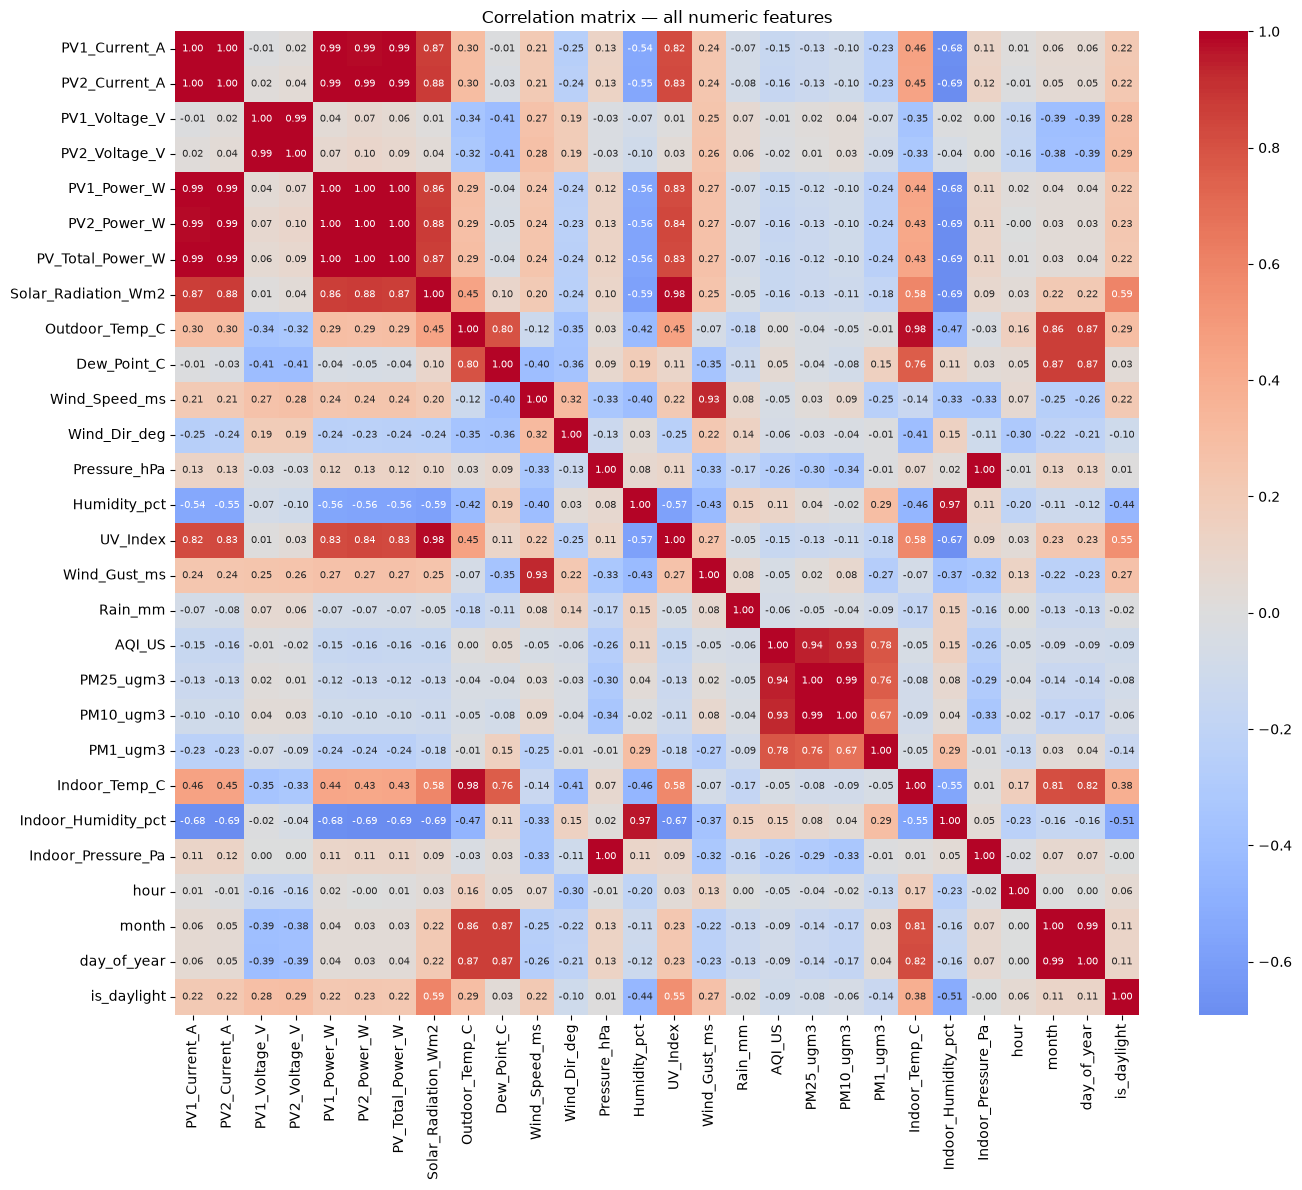

In [5]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["PV_imputed"], errors="ignore")
corr = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation matrix — all numeric features")
plt.tight_layout()
plt.show()

**Observations**:
- Voltage barely correlates with current/power
- `Solar_Radiation_Wm2` (amount of solar energy/radiation reaching a surface) correlates ~0.86–0.88 with power, and `UV_Index` (strength of ultraviolet radiation) correlates 0.98 with `Solar_Radiation_Wm2` itself → these two columns are almost the same signal measured two ways.
- `Humidity_pct` correlates -0.54 to -0.59 with power output. This means: humid air scatters and absorbs sunlight before it reaches the panel.
- `Outdoor_Temp_C` has a modest positive correlation with power. Also `Outdoor_Temp_C` and `Indoor_Temp_C` are highly correlated (same for humidity). This means: the indoor sensor columns are redundant.
- `AQI_US`, `PM25_ugm3`, `PM10_ugm3` are highly correlated (redundancy). Same for `Wind_Speed_ms` and `Wind_Gust_ms`
- `Pressure_hPa` and `Indoor_Pressure_Pa` show a 1.00 correlation

## 4.2 What correlates most with PV power output?

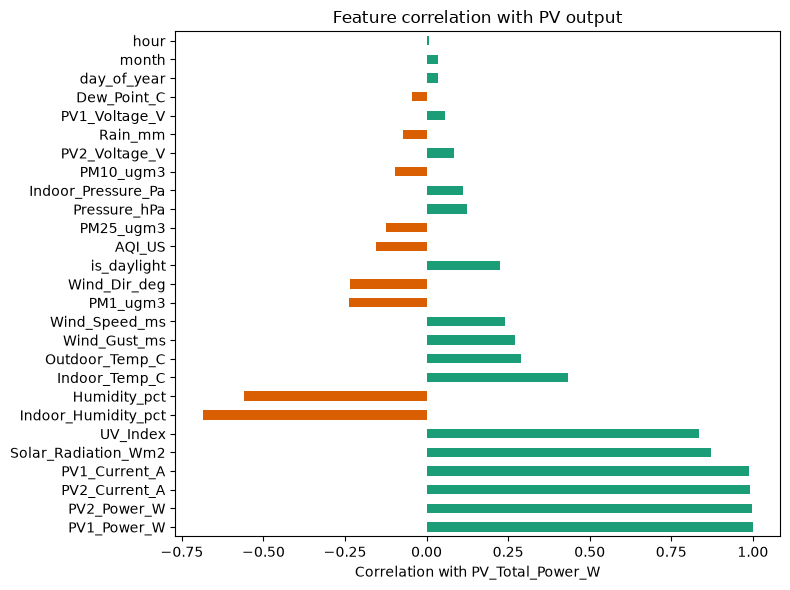

PV1_Power_W            0.998966
PV2_Power_W            0.998887
PV2_Current_A          0.990453
PV1_Current_A          0.989622
Solar_Radiation_Wm2    0.871839
UV_Index               0.834445
Indoor_Humidity_pct   -0.685541
Humidity_pct          -0.560697
Indoor_Temp_C          0.432583
Outdoor_Temp_C         0.289320
Wind_Gust_ms           0.270279
Wind_Speed_ms          0.241134
PM1_ugm3              -0.236688
Wind_Dir_deg          -0.235657
is_daylight            0.224940
AQI_US                -0.155027
PM25_ugm3             -0.124115
Pressure_hPa           0.122816
Indoor_Pressure_Pa     0.111108
PM10_ugm3             -0.097430
PV2_Voltage_V          0.085379
Rain_mm               -0.073716
PV1_Voltage_V          0.056545
Dew_Point_C           -0.043557
day_of_year            0.036001
month                  0.034800
hour                   0.007752
Name: PV_Total_Power_W, dtype: float64

In [6]:
target_corr = corr["PV_Total_Power_W"].drop("PV_Total_Power_W").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
target_corr.plot(kind="barh", color=np.where(target_corr > 0, "#1b9e77", "#d95f02"))
plt.xlabel("Correlation with PV_Total_Power_W")
plt.title("Feature correlation with PV output")
plt.tight_layout()
plt.show()

target_corr